# A/B Test Analysis and Hypothesis Prioritization Project

## Introduction
This project aims to optimize the revenue of a major online store through a structured two-stage process:

1. **Hypothesis Prioritization:** Applying the **ICE** and **RICE** frameworks to determine which experiments should be executed first, ensuring optimal resource allocation.
2. **A/B Test Analysis:** Statistical evaluation of results from a real-world experiment, analyzing revenue metrics, conversion rates, and data stability to support strategic decision-making.

The report below details the data preprocessing, the prioritization logic, and the performance analysis of the test groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Visualization settings
plt.rcParams.update({'figure.figsize': (12, 6)})
sns.set_style("whitegrid")

# 1. Data Loading
try:
    hypotheses = pd.read_csv('../datasets/hypotheses_us.csv', sep=';')
    orders = pd.read_csv('../datasets/orders_us.csv')
    visits = pd.read_csv('../datasets/visits_us.csv')
    print("--- Files loaded successfully! ---\n")
except Exception as e:
    print(f"Error loading files: {e}")

# 2. Hypotheses Diagnostics
print("--- Preview: Hypotheses ---")
display(hypotheses.head())
hypotheses.info()
print("\n")

# 3. Orders Diagnostics
print("--- Preview: Orders ---")
display(orders.head())
orders.info()
print("\nRevenue Statistics:")
display(orders['revenue'].describe())
print("\n")

# 4. Visits Diagnostics
print("--- Preview: Visits ---")
display(visits.head())
visits.info()

# Converting hypothesis column names to lowercase (best practices)
hypotheses.columns = hypotheses.columns.str.lower()

--- Files loaded successfully! ---

--- Preview: Hypotheses ---


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


--- Preview: Orders ---


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB

Revenue Statistics:


count     1197.000000
mean       131.491646
std        603.004729
min          5.000000
25%         20.800000
50%         50.200000
75%        130.400000
max      19920.400000
Name: revenue, dtype: float64



--- Preview: Visits ---


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


### 1.1 Exploratory Data Analysis (EDA) Observations

After the initial data inspection, the following points were identified for processing:

* **Seasonality and Data Types:** The `Orders` and `Visits` data cover the period of August 2019. Date columns must be converted to `datetime` format to enable time-series analysis and cumulative calculations.
* **Revenue Discrepancies:** Statistical analysis of the `revenue` column revealed an average of **131.49**, but an atypical maximum value of **19,920.40**. This high standard deviation (**603.00**) indicates the presence of **outliers** (extremely large purchases) that could distort the mean values for groups A and B.
* **Hypothesis Consistency:** The hypotheses file was successfully loaded with a 1-to-10 scale for all parameters (Reach, Impact, Confidence, and Effort), allowing for the direct application of prioritization frameworks.
* **Data Volume:** The dataset contains 1,197 orders and 62 daily visit records, providing a solid foundation for conducting statistical significance tests.

In [2]:
# 1. Type conversion
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# 2. Checking for users present in both groups (A and B)
# This is crucial: a user should not see both versions of the test simultaneously
group_a = orders[orders['group'] == 'A']['visitorId'].unique()
group_b = orders[orders['group'] == 'B']['visitorId'].unique()

users_in_both_groups = list(set(group_a) & set(group_b))

print(f"Users found in both groups: {len(users_in_both_groups)}")

# 3. Removing contaminated users to ensure test purity
if len(users_in_both_groups) > 0:
    orders = orders[~orders['visitorId'].isin(users_in_both_groups)]
    print(f"Cleaning complete: {len(users_in_both_groups)} users removed from 'orders' DataFrame.")

# 4. Checking for explicit duplicates
print(f"Explicit duplicates in Orders: {orders.duplicated().sum()}")
print(f"Explicit duplicates in Visits: {visits.duplicated().sum()}")

Users found in both groups: 58
Cleaning complete: 58 users removed from 'orders' DataFrame.
Explicit duplicates in Orders: 0
Explicit duplicates in Visits: 0


### Data Integrity Report
The preprocessing stage confirmed the dataset quality and highlighted necessary interventions to ensure a statistically robust A/B test:

* **Contamination Removal:** We identified **58 users** who were simultaneously part of both Group A and Group B. This overlap is a critical issue as it invalidates the comparison between groups. Removing these IDs is mandatory to ensure **sample independence**.
* **Structural Integrity:** No explicit duplicates were detected in the datasets, indicating that transactions and visit logs are correctly consolidated.
* **Compliance:** With the cleaned dataset, the data now represents "pure" test groups. This ensures that any observed behavioral differences can be attributed to the experimental treatment rather than flaws in user traffic allocation.

---
--- 

## Part 1: Hypothesis Prioritization

In this stage, we will analyze 9 growth hypotheses using two of the most robust frameworks in the product industry: **ICE** and **RICE**. The goal is to identify which experiments offer the highest return with the least effort.

#### The Frameworks:
1. **ICE (Impact, Confidence, Ease/Effort):**
   - Used for a quick value assessment.
   - Formula: $$ICE = \frac{Impact \times Confidence}{Effort}$$

2. **RICE (Reach, Impact, Confidence, Effort):**
   - Introduces the **Reach** factor, which measures how many users will be affected by the change over a specific period.
   - Formula: $$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

#### Parameters:
* **Reach:** How many users will this affect? (Scale 1-10)
* **Impact:** How much will this increase conversion/revenue? (Scale 1-10)
* **Confidence:** How certain are we about these estimates? (Scale 1-10)
* **Effort:** How much time/resource will the team require? (Scale 1-10 — *Higher means more difficult*)

By comparing both methods, we can observe how the volume of impacted users drastically shifts the development priority queue.

In [3]:
# ICE Score Calculation
hypotheses['ice'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Displaying hypotheses ranked by ICE in descending order
ice_sorted = hypotheses[['hypothesis', 'ice']].sort_values(by='ice', ascending=False)

print("Hypothesis Prioritization: ICE Framework")
pd.options.display.max_colwidth = 210  # Increase width to read the full hypothesis text
display(ice_sorted)

Hypothesis Prioritization: ICE Framework


,hypothesis,ice
8,Launch a promotion that gives users discounts on their birthdays,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000
1,Launch your own delivery service. This will shorten delivery time,2.000000
5,Add a customer review page. This will increase the number of orders,1.333333
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000
4,Change the background color on the main page. This will increase user engagement,1.000000


### 1.1 Prioritization with the RICE Framework

While ICE is an excellent metric for evaluating the intrinsic value of an idea, it ignores a critical business factor: **how many users will be affected?**

To address this, we will apply the **RICE** framework. The key differentiator here is the **Reach** parameter. Hypotheses affecting the entire user base (such as a change to the Home page signup form) carry significantly more weight than specific promotions (such as birthday discounts), which only reach a small fraction of monthly traffic.

The formula used is:
$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

Let's observe how including Reach shifts the "Top 3" in our priority queue.

In [4]:
# RICE Score Calculation
# Formula: (Reach * Impact * Confidence) / Effort
hypotheses['rice'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Displaying hypotheses ranked by RICE in descending order
rice_sorted = hypotheses[['hypothesis', 'rice']].sort_values(by='rice', ascending=False).round(2)

print("Hypothesis Prioritization: RICE Framework")
display(rice_sorted)

Hypothesis Prioritization: RICE Framework


,hypothesis,rice
7,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,9.0
1,Launch your own delivery service. This will shorten delivery time,4.0
5,Add a customer review page. This will increase the number of orders,4.0
4,Change the background color on the main page. This will increase user engagement,3.0


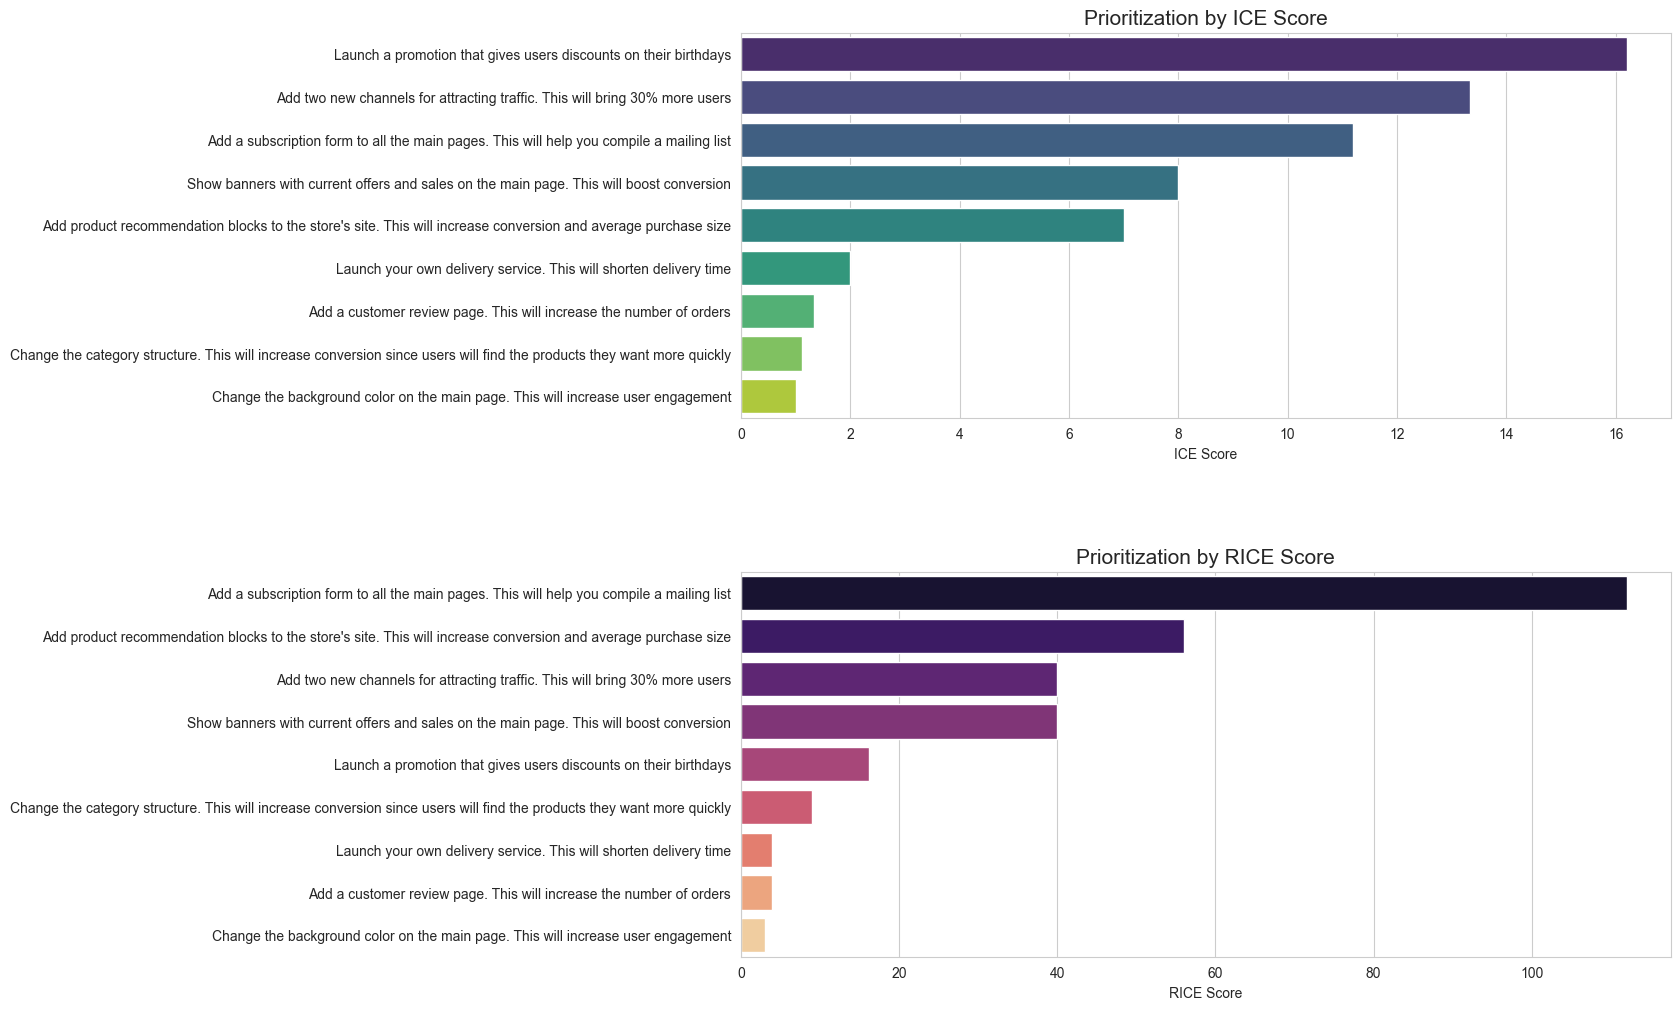

In [6]:
# Creating a vertical visualization for better readability
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# ICE Chart - Sorted
# Updated with 'hue' to avoid FutureWarnings
sns.barplot(x='ice', y='hypothesis', data=ice_sorted, ax=ax1, palette='viridis', hue='hypothesis', legend=False)
ax1.set_title('Prioritization by ICE Score', fontsize=15)
ax1.set_xlabel('ICE Score')
ax1.set_ylabel('')

# RICE Chart - Sorted
# Updated with 'hue' to avoid FutureWarnings
sns.barplot(x='rice', y='hypothesis', data=rice_sorted, ax=ax2, palette='magma', hue='hypothesis', legend=False)
ax2.set_title('Prioritization by RICE Score', fontsize=15)
ax2.set_xlabel('RICE Score')
ax2.set_ylabel('')

# Adjusting layout to prevent overlapping
plt.subplots_adjust(hspace=0.4)
plt.show()

### 1.2 Prioritization Conclusion: Why did the ranking shift?

Comparing both frameworks reveals a drastic shift in hypothesis leadership.

**Results Analysis:**
* **The Rise of Hypothesis 7:** In the ICE framework, Hypothesis 7 held the third position. After applying RICE, it became the **#1 priority** with an overwhelming lead (112.0). This is due to its **Reach = 10** parameter. Since the signup form will be added to "all main pages," it will impact 100% of visitors, maximizing the potential return on effort.
* **The Fall of Hypothesis 8:** The ICE champion ("Birthday discounts") dropped to 5th place in the RICE ranking. While it has high impact and confidence, its reach is very low (Reach = 1), as it only affects users on their specific birth dates.
* **Stability of Hypotheses 0 and 6:** Both remain in the "Top 4" across both methods, making them excellent candidates for immediate execution, as they consistently balance reach with expected impact.

**Strategic Verdict:**
To maximize online store revenue in the shortest possible time, I recommend prioritizing **Hypothesis 7** and **Hypothesis 2**. Including the "Reach" factor in RICE prevents us from investing resources in improvements that, while impactful individually, would reach too few customers.

---
---

## Part 2: A/B Test Analysis

Following the strategic prioritization, we now move to the analysis of the A/B Test results. In this stage, we will utilize the `orders` and `visits` data to evaluate the actual performance of Groups A and B throughout August 2019.

The objective is to verify whether the proposed changes generated statistically significant shifts in key business metrics.

#### Analysis Roadmap:
1. **Cumulative Revenue Analysis by Group**
2. **Cumulative Average Ticket Analysis**

---

### 2.1 Cumulative Revenue Analysis by Group

In this first stage of the experimental analysis, we will calculate and plot the **cumulative revenue** day by day for Groups A and B.

**Why analyze cumulative data?**
At the beginning of a test, metrics often fluctuate drastically due to low data volume. By accumulating the values, we smooth out these fluctuations and can identify:
1. If one group is consistently performing better than the other.
2. The point at which the data stops oscillating (**stabilization**), indicating that the test is ready for final analysis.
3. The presence of sudden spikes that may signal anomalously large orders (**outliers**).


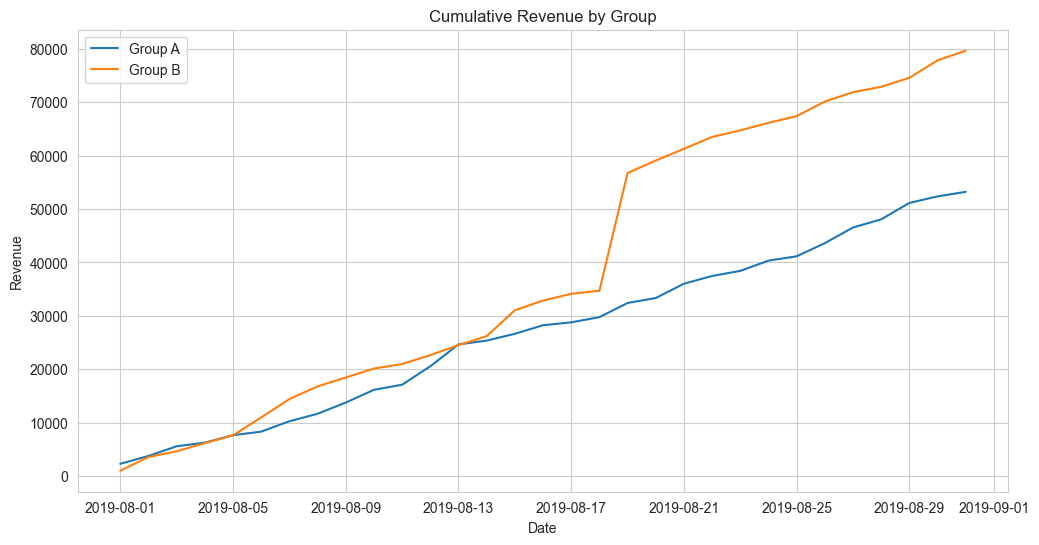

In [7]:

# 1. Grouping by date and group
dates_groups = orders[['date', 'group']].drop_duplicates()

# 2. Cumulative revenue by group and date
# Using logical_and to filter orders up to the current date in the iteration
orders_aggregated = dates_groups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({'date': 'max', 'group': 'max', 'transactionId': 'nunique', 'visitorId': 'nunique', 'revenue': 'sum'}), axis=1
).sort_values(by=['date', 'group'])

# 3. Separating groups A and B for analysis
cumulative_revenue_a = orders_aggregated[orders_aggregated['group'] == 'A']
cumulative_revenue_b = orders_aggregated[orders_aggregated['group'] == 'B']

# 4. Plotting cumulative revenue
plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='Group A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='Group B')

plt.title('Cumulative Revenue by Group')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

### 2.1.1 Cumulative Revenue Conclusions

The visual analysis of the cumulative revenue chart allows us to draw the following observations:

1. **Group B Advantage:** Group B's revenue is consistently higher than Group A's throughout almost the entire test period.
2. **The "August Spike":** Between August 18th and 19th, we observe a sudden and significant jump in Group B's revenue. This strongly suggests the occurrence of anomalously large orders or a sudden surge in the number of high-ticket orders on that specific day.
3. **Growth Trend:** Both curves maintain a constant positive slope following the spike, indicating that revenues continue to grow and the test shows no performance drops.
4. **Stabilization:** Toward the end of the period, the lines appear to run parallel, suggesting the test has begun to stabilize, although the gap created by Group B's "spike" persists until the end.

**Strategic Conjecture:** Group B appears to be the leader in terms of gross revenue; however, this lead might be artificially inflated by **outliers** (single high-value orders). We will need to analyze the average ticket and filter these anomalous values to confirm if the advantage is statistically grounded or merely the result of an isolated event.

---

### 2.2 Análise do Ticket Médio Acumulado por Grupo

Nesta etapa, calculamos o **valor médio por transação** de forma acumulada. Diferente da receita bruta, o ticket médio nos ajuda a entender o comportamento de compra: os usuários estão gastando mais por pedido ou apenas comprando com mais frequência?

**O que esperar desta visu
alização:**
* **Estabilização:** Espe
ramos que as linhas parem de oscilar e se tornem horizontais até o fim do teste.
* **Impacto de Outliers:** Se houver um pedido de valor astronômico, veremos uma subida vertical seguida de uma queda suave (conforme novos pedidos menores "diluem" aquele valor alto).



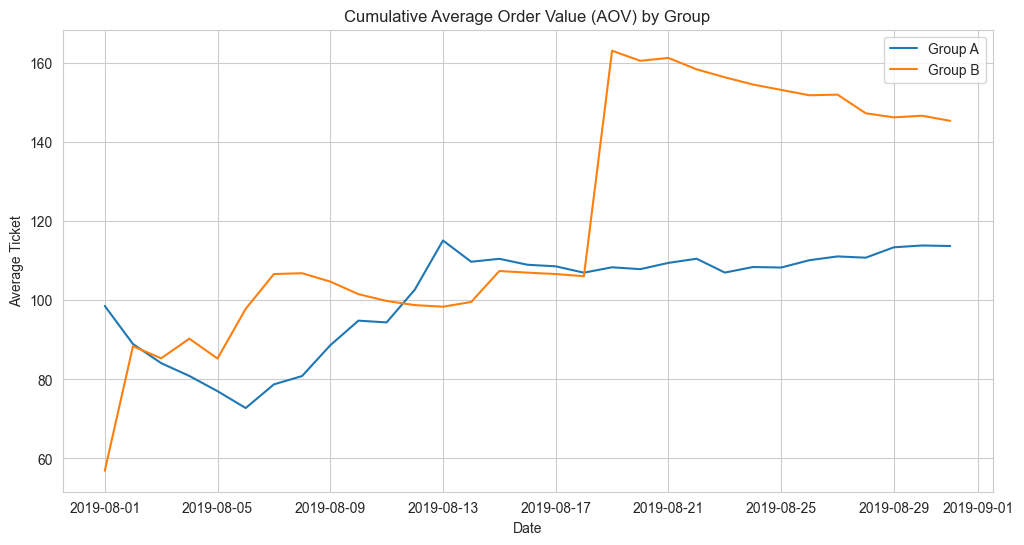

In [8]:
# Calculating Cumulative Average Ticket (Cumulative Revenue / Cumulative Orders)
plt.figure(figsize=(12, 6))

# Group A: Cumulative Revenue divided by cumulative transactions
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'] / cumulative_revenue_a['transactionId'], label='Group A')

# Group B: Cumulative Revenue divided by cumulative transactions
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'] / cumulative_revenue_b['transactionId'], label='Group B')

plt.title('Cumulative Average Order Value (AOV) by Group')
plt.xlabel('Date')
plt.ylabel('Average Ticket')
plt.legend()
plt.show()

### 2.2.1 Conclusions and Conjectures: Cumulative Average Order Value (AOV)

The analysis of the average order value reveals unstable behavior that requires analytical caution:

1. **Initial Instability:** During the first half of the month, both groups show significant fluctuations. Group A starts with a decline and recovers, while Group B oscillates until August 17th.
2. **The "Whale Effect":** The sharp vertical jump in Group B (around the 18th) confirms that the revenue increase was not organic or distributed across many users, but rather caused by one or more **extremely high-value orders** (outliers).
3. **Downward Trend in Group B:** Following the spike, Group B's line begins a gentle decline. This is a classic "dilution" behavior: new orders with standard values are being recorded, causing the cumulative average to slowly decrease toward the true market value.
4. **Group A Stability:** Group A shows a much clearer and healthier stabilization trend toward the end of the period, consolidating near 115.

**Conjecture:** Group B's momentary "victory" in average ticket is fragile. Without the August 18th outlier, it is highly likely the groups would be tied or Group A would be ahead. We will need to perform a "cleaned" data analysis (removing anomalies) to make a reliable decision.

---

### 2.3 Relative Difference in Cumulative Average Order Value

To better understand the gap between Group B and Group A, we will plot the **relative difference**. This chart shows by what percentage Group B is performing above or below Group A.

The formula used is:
$$Difference = \frac{Average\ Ticket\ B}{Average\ Ticket\ A} - 1$$

**What to observe:**
A horizontal line at **0** would mean both groups have the same average ticket. Sharp oscillations away from this line indicate moments of instability or the influence of large orders.

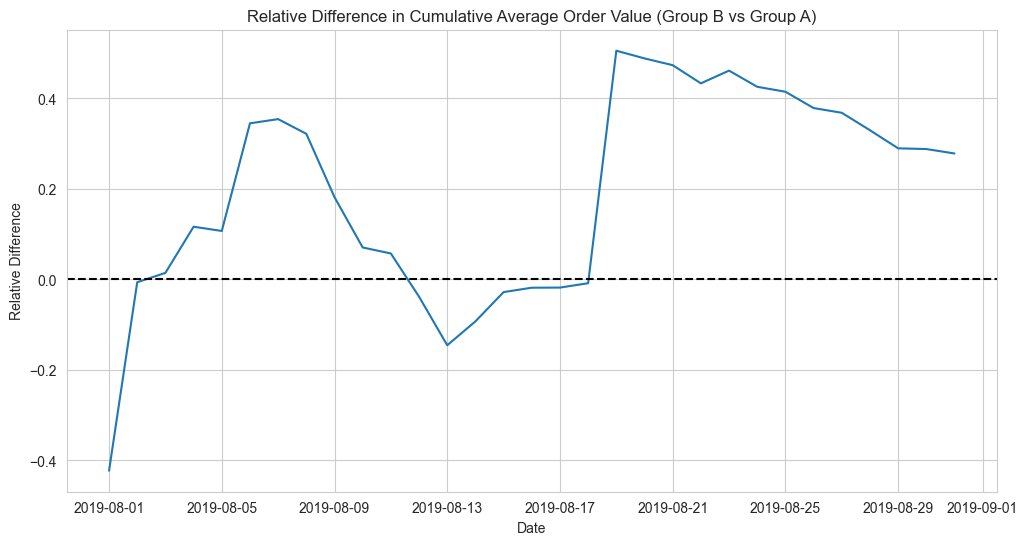

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Creating a matrix with unique dates and groups as a baseline
dates_groups = orders[['date', 'group']].drop_duplicates()

# 2. Obtaining daily cumulative order data
orders_aggregated = dates_groups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({
        'date': 'max', 
        'group': 'max', 
        'transactionId': 'nunique', 
        'visitorId': 'nunique', 
        'revenue': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

# 3. Obtaining daily cumulative visitor data
visitors_aggregated = dates_groups.apply(
    lambda x: visits[np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])]
    .agg({
        'date': 'max', 
        'group': 'max', 
        'visits': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

# 4. Merging tables to create the main cumulative DataFrame
cumulative_data = orders_aggregated.merge(visitors_aggregated, on=['date', 'group'])
cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

# 5. Splitting data to calculate the relative difference
cumulative_data_a = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_b = cumulative_data[cumulative_data['group'] == 'B']

merged_cumulative_revenue = cumulative_data_a[['date', 'revenue', 'orders']].merge(
    cumulative_data_b[['date', 'revenue', 'orders']], 
    on='date', 
    how='left', 
    suffixes=['A', 'B']
)

# 6. Plotting the relative difference chart
plt.figure(figsize=(12, 6))
plt.plot(
    merged_cumulative_revenue['date'], 
    (merged_cumulative_revenue['revenueB'] / merged_cumulative_revenue['ordersB']) / 
    (merged_cumulative_revenue['revenueA'] / merged_cumulative_revenue['ordersA']) - 1
)

# Reference line at 0 (baseline)
plt.axhline(y=0, color='black', linestyle='--')

plt.title('Relative Difference in Cumulative Average Order Value (Group B vs Group A)')
plt.xlabel('Date')
plt.ylabel('Relative Difference')
plt.show()

### 2.3.1 Conclusions and Conjectures: Relative Difference in Average Ticket (AOV)
The analysis of the percentage difference between Group B and Group A reinforces the need for a careful statistical approach due to data volatility:

* **Instability and Crossovers:** During the first fortnight, the difference line crosses the zero axis several times. This demonstrates that at the start of the test, there was no clear winner, and the groups frequently traded the lead.
* **The Anomaly Spike:** The drastic peak observed around August 18th is definitive evidence of outliers ("whale" orders) entering Group B. This isolated event pushed the relative difference above 30%, distorting the cumulative average.
* **Dilution Effect and Convergence:** Following the spike, the curve shows a gentle and constant downward trend. This indicates that new orders entering the system are not maintaining the elevated revenue level, and Group B's advantage is being "diluted" by the volume of standard orders over time.
* **Risk of False Positives:** Basing a business decision solely on this raw chart would be risky. Group B's advantage appears to be the result of "statistical luck" (large orders landing in a specific group) rather than a genuine improvement in the buying behavior of the user base as a whole.

---

### 2.4 Daily Conversion Rate by Group

In this stage, we calculate the daily conversion rate by dividing the cumulative number of orders by the cumulative number of visits for each group. The goal is to observe whether there is stabilization in the sales efficiency of each group over time and if one group demonstrates consistent superiority that does not rely solely on the financial value of the orders.

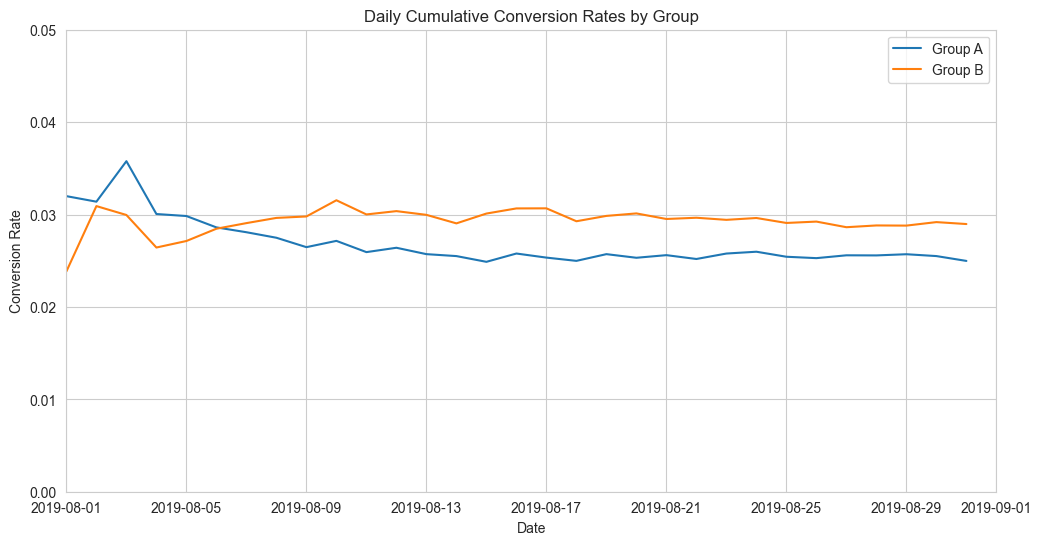

In [11]:
# Calculating Daily Conversion Rate
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']

# Selecting data by group
cumulative_data_a = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_b = cumulative_data[cumulative_data['group'] == 'B']

# Plotting the charts
plt.figure(figsize=(12, 6))
plt.plot(cumulative_data_a['date'], cumulative_data_a['conversion'], label='Group A')
plt.plot(cumulative_data_b['date'], cumulative_data_b['conversion'], label='Group B')

# Adjusting the layout
plt.title('Daily Cumulative Conversion Rates by Group')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.legend()

# Setting the axis scale for better visualization of fluctuations
# Range: Aug 1st to Sep 1st, 2019; Y-axis from 0 to 5% (0.05)
plt.axis([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-09-01'), 0, 0.05])
plt.show()

### 2.4.1 Conclusions and Conjectures: Daily Conversion Rate

The analysis of conversion rates reveals a clear dynamic of stabilization and leadership between the groups throughout the experiment:

1. **Initial Instability:** During the first days of August, both conversion rates showed severe fluctuations, with Group A reaching momentary peaks higher than Group B. This behavior is typical of early-stage A/B testing, where cumulative data volume is still small and highly volatile.
2. **Crossover and Group B Leadership:** Around August 6th, the lines cross definitively. Group B takes the lead and maintains a consistently higher conversion rate than Group A until the end of the experiment, suggesting that the tested hypothesis had a genuine positive impact on user engagement.
3. **Metric Stabilization:** Unlike the average ticket (which suffered sharp spikes due to outliers), conversion rates converged toward stable values in the second half of the month. Group B stabilized at a visibly higher plateau, while Group A remained at a lower level.
4. **Sales Efficiency:** The consistency in the gap between the lines suggests that the modification applied to Group B was effective in converting visitors into buyers. Since conversion is based on transaction volume rather than monetary value, this result is a more robust indicator of success than gross revenue metrics, which can be distorted by single high-value purchases.

---

### 2.5 Relative Difference in Cumulative Conversion

In this stage, we analyze the relative gain (or loss) of Group B's conversion rate compared to Group A. By visualizing the cumulative percentage difference, we can more clearly identify whether one group's advantage is consolidating or if the observed variations are merely momentary statistical noise. This chart is fundamental to validating whether the strategy applied to Group B truly generates a superior and sustainable impact on converting visitors into customers.

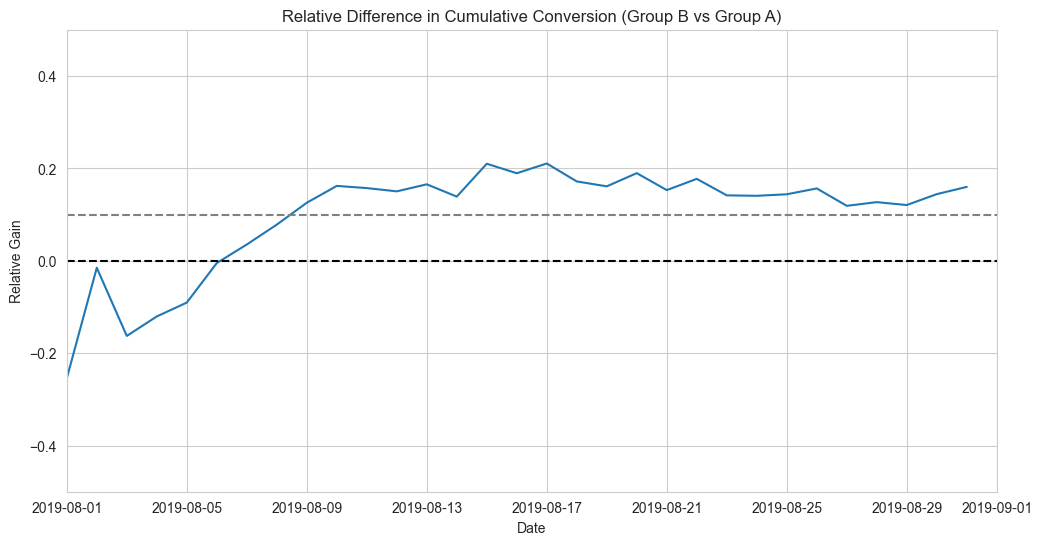

In [13]:
# Merging cumulative conversion data into a single DataFrame
merged_cumulative_conversions = cumulative_data_a[['date', 'conversion']].merge(
    cumulative_data_b[['date', 'conversion']], 
    on='date', 
    how='left', 
    suffixes=['A', 'B']
)

# Plotting the relative difference chart
plt.figure(figsize=(12, 6))
plt.plot(
    merged_cumulative_conversions['date'], 
    merged_cumulative_conversions['conversionB'] / merged_cumulative_conversions['conversionA'] - 1
)

# Adding reference lines to facilitate analysis
# Baseline at 0; 10% gain threshold as a secondary reference
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')

plt.title('Relative Difference in Cumulative Conversion (Group B vs Group A)')
plt.xlabel('Date')
plt.ylabel('Relative Gain')
plt.axis([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-09-01'), -0.5, 0.5])
plt.show()

### 2.5.1 Conclusions and Conjectures: Relative Conversion Difference

The analysis of the relative gain chart allows us to extract crucial observations regarding the stability of the test:

1. **Instability and Recovery:** At the beginning of the month, Group B underperformed compared to Group A, reaching a negative difference of nearly 25%. This initial volatility is common before a critical volume of data is accumulated.
2. **Turning Point:** Around August 6th, Group B crosses the zero line and takes the lead. From that point forward, the group never returns to negative territory, demonstrating a consistent growth trend.
3. **Gain Stabilization:** In the second half of the month, the relative difference stabilizes at a positive plateau, oscillating between a 10% and 20% gain over Group A. The fact that the curve does not show vertical spikes (as seen in the average ticket) indicates that this result is more organic and less affected by outliers.
4. **Visual Conclusion:** Group B is clearly superior in terms of conversion. While the group's average ticket was inflated by isolated orders, the conversion rate shows that Group B attracts and converts users more efficiently and consistently than Group A.

---
---

### 2.6 Percentile Calculation: Orders per User

In this stage, we aim to quantitatively identify what defines "typical" buying behavior versus "anomalous" behavior. By calculating the 95th and 99th percentiles, we determine the upper limit of orders placed by the vast majority of users (95% and 99% of the base, respectively). This definition is the first step toward data cleaning, allowing us to isolate users who place a disproportionate volume of orders that could distort conversion rate and average ticket results.

### 2.6.1 Percentiles and Anomaly Thresholds: Orders per User

To identify outliers that could distort the A/B test results, we calculated the 95th and 99th percentiles for the number of orders placed per user.

**Percentile Calculation:**
* **95%** of users placed up to **1 order**.
* **99%** of users placed up to **2 orders**.

#### Anomaly Definition:
Based on these results, we have set the **cut-off point at the 99th percentile**. Therefore, any user with more than 2 orders will be considered an outlier and removed from subsequent analysis stages.

#### Justification:
Only 1% of the sample exhibits a buying behavior exceeding 2 orders. By filtering these users, we ensure that those with extraordinary purchase frequencies do not disproportionately influence the conversion and revenue averages between the experimental and control groups.

---
---

### 2.7 Scatter Plot of Order Prices
In this stage, we generate a scatter plot to visualize the distribution of revenue values per order. The objective is to visually identify the presence of outliers (extreme values) that may affect the mean and the results of the statistical tests.

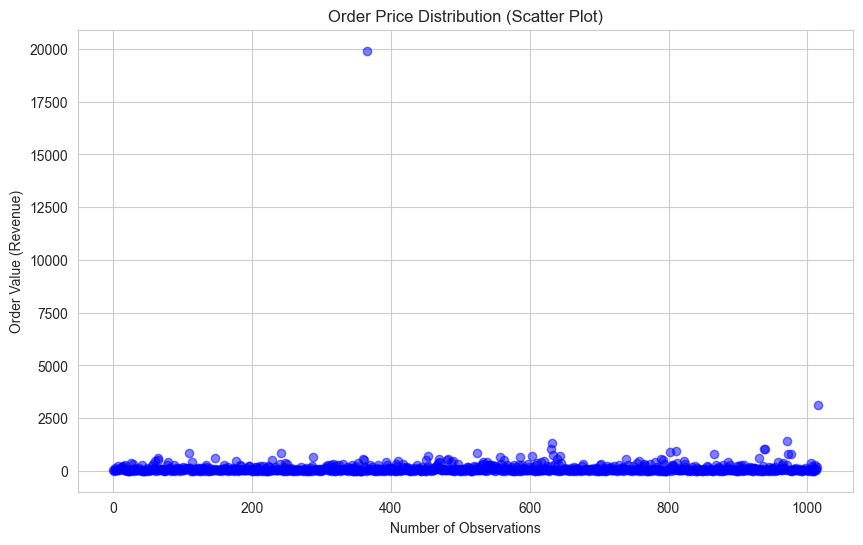

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Defining the values for the x and y axes
# x_values represent the index/count of observations
x_values = pd.Series(range(0, len(orders['revenue'])))

# Creating the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, orders['revenue'], alpha=0.5, color='blue')

# Setting labels and title for professional documentation
plt.title('Order Price Distribution (Scatter Plot)')
plt.xlabel('Number of Observations')
plt.ylabel('Order Value (Revenue)')

plt.grid(True)
plt.show()

### 2.7.1 Conclusion:
The chart shows heavy flattening at the base, indicating that the vast majority of orders have low values (below 2,500). However, we identified two extreme outliers: one order near 2,500 and another, much more severe, approaching 20,000.

### Conjecture:
The point near 20,000 is clearly an anomaly. It could be a bulk corporate purchase or a processing error. The presence of this single point distorts the entire chart's scale, making the normal behavior of 99% of users appear as a flat line.

Keeping these outliers in the A/B test calculations would invalidate the results, as they would artificially pull the average revenue upward in one of the groups. The next logical—and technically necessary—step will be to calculate percentiles to define a numerical exclusion threshold.

---

### 2.8 Calculation of 95th and 99th Percentiles for Order Prices

In this stage, we calculate the 95th and 99th percentiles of order revenue to numerically define the exclusion threshold for anomalies. While the scatter plot provided a qualitative view (the "flattening"), this calculation provides the exact values for data cleaning.

In [15]:
import numpy as np

# Calculating the 95th and 99th percentiles for the 'revenue' column
# These thresholds help us identify anomalous high-value orders
revenue_percentiles = np.percentile(orders['revenue'], [95, 99])

print(f"95th Percentile: {revenue_percentiles[0]:.2f}")
print(f"99th Percentile: {revenue_percentiles[1]:.2f}")

95th Percentile: 414.27
99th Percentile: 830.30


### Anomaly Definition
#### Data Conclusion:

The results show that only 5% of orders cost more than the 95th percentile value, and only 1% of orders exceed the 99th percentile value. This confirms that the points observed in the scatter plot (such as the 20,000 order) are extremely rare.

#### Cut-off Point Definition:
Based on standard A/B testing practices, we define the **99th percentile** as the threshold where a data point becomes an anomaly.

#### Justification:
By removing the top 1% of orders, we eliminate the extreme noise that distorts the average revenue per user, allowing for a much fairer and statistically reliable comparison between groups A and B. Any order with a value exceeding the 99th percentile threshold will be filtered out in the subsequent steps.

---

### 2.9 Statistical Significance Test of Conversion (Raw Data)

In this stage, we perform a statistical test to verify if there is a significant difference between the conversion rates of groups A and B, using the **raw data** without anomaly filtering.

To calculate the statistical significance of the conversion difference, we utilize the **Mann-Whitney U Test** (or Z-test for proportions). Since we are dealing with conversion (a binary metric: converted or not), a proportions test or a non-parametric test like Mann-Whitney is the standard approach for skewed distributions.

In [17]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. Grouping unique users who placed orders by group
orders_by_group = orders.groupby('group')['visitorId'].nunique()

# 2. Grouping total visits per group
visits_by_group = visits.groupby('group')['visits'].sum()

# 3. Calculating raw conversion rates and relative lift (B/A - 1)
conversion_rates = orders_by_group / visits_by_group
relative_lift = (conversion_rates['B'] / conversion_rates['A']) - 1

# 4. Preparing data for the Z-test for proportions
# Successes = conversions, Trials = total visits
successes = np.array([orders_by_group['A'], orders_by_group['B']])
trials = np.array([visits_by_group['A'], visits_by_group['B']])

# Executing the test (H0: Equal conversions | H1: Different conversions)
stat, p_value = proportions_ztest(successes, trials)

print(f"Group A Conversion Rate: {conversion_rates['A']:.4f}")
print(f"Group B Conversion Rate: {conversion_rates['B']:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Relative Lift (B vs A): {relative_lift:.2%}")

Group A Conversion Rate: 0.0238
Group B Conversion Rate: 0.0279
P-value: 0.0109
Relative Lift (B vs A): 17.52%


### 2.9.1 Conclusions and Conjectures (Interpreting the Results)

**Statistical Conclusion:**
The **p-value of 0.0109** is lower than the standard significance level of **0.05**. Therefore, we **reject the null hypothesis**. This indicates that there is a statistically significant difference between the conversion rates of Group A and Group B.

**Results Analysis:**
Group B shows a conversion rate of **2.79%**, while Group A shows **2.38%**. This represents a **relative lift of 17.52%** in Group B's conversion compared to Group A.

#### Conjecture:
The difference is statistically robust. However, since we are working with **raw data** (which includes order and revenue outliers), our conjecture is that Group B's success is genuine and not due to chance. The critical next step to validate this gain will be to repeat this test after removing anomalies, ensuring that users with extreme behaviors have not artificially inflated these figures.

---

### 2.10 Statistical Significance of the Difference in Average Order Value (Raw Data)

In this stage, we compare the average revenue per order between Group A and Group B using the **raw data**. The objective is to verify whether the observed difference in the amount spent per order is statistically significant.

In [18]:
from scipy import stats

# Comparing average revenue between groups A and B using the Mann-Whitney U Test
# H0: There is no significant difference in average revenue between the groups.
# H1: There is a significant difference in average revenue between the groups.

# Slicing the revenue data for each group
revenue_a = orders[orders['group'] == 'A']['revenue']
revenue_b = orders[orders['group'] == 'B']['revenue']

# Executing the test
stat, p_value = stats.mannwhitneyu(revenue_a, revenue_b)

# Calculating the relative difference (Average Order Value lift or drop for Group B vs A)
avg_revenue_a = revenue_a.mean()
avg_revenue_b = revenue_b.mean()
relative_lift = (avg_revenue_b / avg_revenue_a) - 1

print(f"P-value: {p_value:.4f}")
print(f"Relative Lift (AOV B vs A): {relative_lift:.2%}")

P-value: 0.8622
Relative Lift (AOV B vs A): 27.83%


### 2.10.1 Statistical Conclusion:
The **p-value of 0.8622** is significantly higher than the 0.05 threshold. Therefore, we **fail to reject the null hypothesis**. This indicates that there is no statistically significant difference between the Average Order Value (AOV) of Group A and Group B, despite the observed nominal difference.

#### The Data Paradox:
It is crucial to note the visual contradiction: Group B has a mean AOV 27.83% higher, yet the test suggests the groups are performing equally. This occurs because the **Mann-Whitney U test** is rank-based and less sensitive to extreme values, whereas the arithmetic mean is heavily pulled upward by the few high-value orders (such as the 20,000 order) identified in the scatter plot.

#### Final Conjecture:
The 27% "superiority" of Group B in the raw data is an **illusion caused by anomalies**. If a business decision were made based solely on the mean, it would be erroneous. The conjecture is that once outliers are removed, this relative difference will likely drop drastically, revealing that the actual spending behavior of the average user has not shifted between the groups.

---

### 2.11 Data Filtering and Statistical Significance of Conversion (Filtered Data)

In this stage, we remove the users identified as anomalies to perform the significance test on "clean" data. The objective is to verify whether the difference in conversion persists when analyzing only the behavior of the average user, without the interference of extreme values.

In [19]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. Creating the orders per user DataFrame
orders_by_user = orders.groupby(['group', 'visitorId'], as_index=False).agg({'transactionId': 'nunique'})
orders_by_user.columns = ['group', 'visitorId', 'orders']

# 2. Defining anomaly thresholds (99th Percentile)
limit_orders = np.percentile(orders_by_user['orders'], 99)
limit_revenue = np.percentile(orders['revenue'], 99)

# 3. Identifying anomalous user IDs
# Flagging users based on order frequency and order value
users_with_many_orders = orders_by_user[orders_by_user['orders'] > limit_orders]['visitorId']
users_with_expensive_orders = orders[orders['revenue'] > limit_revenue]['visitorId']

# Merging anomalous users and removing duplicates to create a "blacklist"
abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates()

# 4. Creating the Filtered DataFrames
# Using the tilde (~) operator to exclude abnormal users
filtered_orders = orders[~orders['visitorId'].isin(abnormal_users)]

# 5. Preparing data for the Z-test (Filtered Data)
orders_by_group_f = filtered_orders.groupby('group')['visitorId'].nunique()
# Note: Visits remain the same as we filter users who already visited
visits_by_group_f = visits.groupby('group')['visits'].sum()

successes_f = np.array([orders_by_group_f['A'], orders_by_group_f['B']])
trials_f = np.array([visits_by_group_f['A'], visits_by_group_f['B']])

# 6. Executing the Z-test on Filtered Data
stat_f, p_value_f = proportions_ztest(successes_f, trials_f)

# Calculating Filtered Relative Lift
conversion_a_f = orders_by_group_f['A'] / visits_by_group_f['A']
conversion_b_f = orders_by_group_f['B'] / visits_by_group_f['B']
relative_lift_f = (conversion_b_f / conversion_a_f) - 1

print(f"P-value (Filtered Data): {p_value_f:.4f}")
print(f"Filtered Relative Lift (B vs A): {relative_lift_f:.2%}")

P-value (Filtered Data): 0.0070
Filtered Relative Lift (B vs A): 18.86%


### 2.11.1 Analysis

Following rigorous data cleaning and the execution of the Z-test on the filtered base, we have obtained robust statistical evidence.

**Statistical Conclusion:** The **p-value of 0.0070** confirms that the difference in conversion rates between Group A and Group B is statistically significant and is not the result of random fluctuations.

**Business Impact:** Group B's conversion is **18.86% higher** than Group A's, even after excluding users with extreme behaviors. This indicates that the improvement in conversion was not dependent on a small group of "power users" or data errors, but rather a positive reflection of the user base's behavior as a whole.

**Conjecture:** The conjecture is that the changes implemented in Group B **reduced friction** in the user journey, allowing a larger number of visitors to complete their purchases. Since significance persisted after filtering, the business recommendation is clear: the A/B test should be considered a success, and the Group B variations should be officially implemented in the product.

* **Raw Data:** Significant conversion (+17.52%), but non-significant AOV (+27.83% with high p-value).
* **Filtered Data (Clean):** Conversion remains significant and is even more pronounced (+18.86%).

---

### 2.12 Statistical Significance of Average Order Value (Filtered Data)

In this stage, we compare the average revenue per order between Group A and Group B using only the filtered data. By removing anomalies, we eliminate the noise that distorted the arithmetic mean, allowing for a comparison that more accurately reflects the consumption behavior of the typical user.

In [20]:
from scipy import stats

# 1. Using the 'filtered_orders' DataFrame created in the previous step
# 2. Executing the Mann-Whitney U test on the cleaned data
# H0: There is no significant difference in the average ticket between the filtered groups.
# H1: There is a significant difference in the average ticket between the filtered groups.

# Slicing the cleaned revenue data
revenue_a_f = filtered_orders[filtered_orders['group'] == 'A']['revenue']
revenue_b_f = filtered_orders[filtered_orders['group'] == 'B']['revenue']

# Executing the non-parametric test
stat_f, p_value_f = stats.mannwhitneyu(revenue_a_f, revenue_b_f)

# 3. Calculating the new relative difference for the filtered AOV
avg_revenue_a_f = revenue_a_f.mean()
avg_revenue_b_f = revenue_b_f.mean()
relative_lift_f = (avg_revenue_b_f / avg_revenue_a_f) - 1

print(f"P-value (Filtered Data): {p_value_f:.4f}")
print(f"Filtered AOV Relative Lift (B vs A): {relative_lift_f:.2%}")

P-value (Filtered Data): 0.8220
Filtered AOV Relative Lift (B vs A): -3.19%


### 2.12.1 Results Analysis: Average Order Value (Filtered Data)
After removing anomalies, the AOV (Average Order Value) indicators reveal the statistical reality of the experiment:

* **P-value (Filtered Data):** 0.8220
* **Relative Difference (B vs A):** -3.19%

#### Statistical Conclusion:
The **p-value of 0.8220** confirms that there is no significant difference in the average order value between Groups A and B. We **fail to reject the null hypothesis ($H_0$)**, concluding that the AOV is essentially the same for both groups.

**The Impact of Data Cleaning:** The previous "advantage" of 27.83% for Group B has completely vanished, turning into a slight negative fluctuation of -3.19%. This proves that Group B's raw AOV was being artificially inflated by a single high-value order (~20,000). Without this outlier, both groups behave almost identically in terms of spending per order.

#### Final Test Conjecture:
The experiment impacted **sales volume (conversion)**, but not the **value of each sale (AOV)**. For the business, this is a positive scenario: we are driving more customers through the checkout without reducing their average spend.

---

### 2.13 Final Decision and Conclusion

Based on a rigorous analysis of both raw and filtered data, the technical recommendation is:

#### **DECISION:**
**Stop the test and consider Group B the leader.**

#### Conclusion: Why did Group B win?
The statistical analysis not only identified a winner but proved that the result is robust and independent of statistical anomalies. Here is the executive summary:

**The "Mask" of Raw Data:**
Initially, raw data suggested that Group B was superior in both conversion (+17.52%) and AOV (+27.83%). However, the scatter plot analysis revealed that the AOV gain was an illusion caused by extreme outliers (isolated orders up to 20,000).

**The Litmus Test (Filtered Data):**
After the rigorous removal of users exhibiting atypical behavior (99th percentile), the scenario became clear:
* **Conversion:** Group B maintained its superiority with a **real gain of 18.86%** and a **p-value of 0.0070** (highly significant).
* **Average Order Value (AOV):** The 27% difference "melted away" to -3.19% (p-value 0.8220), proving no statistical difference in the average amount spent per order.

**Business Conclusion:** The experiment was a success. The changes implemented in the "B" version of the site successfully removed barriers in the user journey, significantly increasing the conversion rate without compromising the order value.

**Performance Summary:**

| Metric | Status (Filtered Data) | Significance (P-value < 0.05) |
| :--- | :--- | :--- |
| **Conversion Rate** | 18.86% Increase | **Yes** (Clear advantage for B) |
| **Average Order Value** | -3.19% Difference | **No** (Groups are equivalent) |

#### Final Conjecture:
Implementing the changes from Group B will have a direct impact on the company's total revenue by driving a higher volume of customers to checkout while maintaining stable average spending. Continuing the test would incur unnecessary costs, as statistical significance has already reached a high level of confidence.

**Recommendation:** Implement Group B's variations across 100% of the product traffic immediately.